In [2]:
import pickle
import os, sys
from pathlib import Path
import pandas as pd

from nre.preprocess import preprocess_df
from nre.analyze_nf_dataset import split_df, flow_based_classification

import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from PIL import Image
import pickle
import seaborn as sns

from test_network_model_graph import generate_random_mvn_model, samples2flows
from test_flow_based_classification import generate_n_flow_modes, simulate_attack, flow_based_classification
from test_nre_classification import generate_n_state_flows

In [3]:
import importlib
import nre.analyze_nf_dataset

importlib.reload(nre.analyze_nf_dataset)
from nre.analyze_nf_dataset import *

# Simulated Data

## Flow-Based Classification

In [4]:
import importlib
import test_flow_based_classification

importlib.reload(test_flow_based_classification)
from test_flow_based_classification import *

Text(0.5, 1.0, 'Flow Features of Modes')

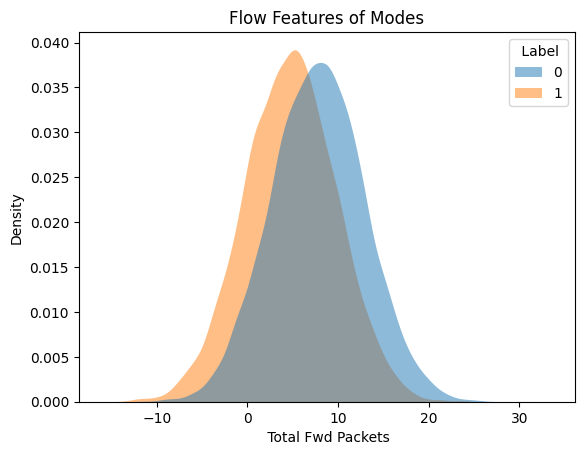

In [5]:
df_test, _ = generate_n_flow_modes(2)
sns.kdeplot(data=df_test, x=' Total Fwd Packets', hue=' Label', fill=True, alpha=0.5, linewidth=0)
plt.title('Flow Features of Modes')

In [6]:
df_test[' Label'].describe()

count     20000
unique        2
top           0
freq      10000
Name:  Label, dtype: object

In [7]:
df_test.describe()

,Timestamp
count,20000
mean,2023-06-06 00:34:40
min,2023-06-06 00:00:00
25%,2023-06-06 00:17:25.052255232
50%,2023-06-06 00:34:50
75%,2023-06-06 00:51:54.948744704
max,2023-06-06 01:09:00


Text(0.5, 1.0, 'Flow Features of Modes')

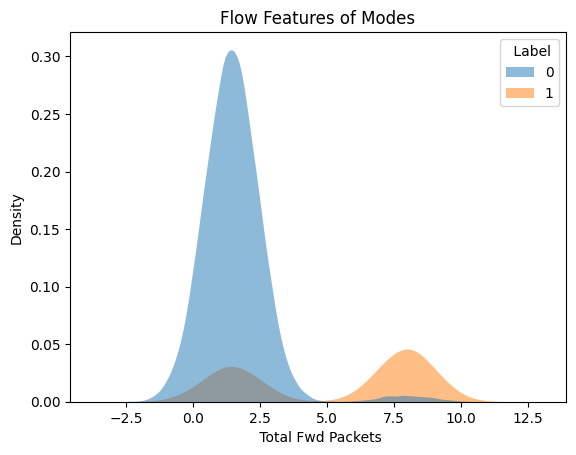

In [8]:
df_test, flow_means = simulate_attack(p_attack=0.1, n_flow=1000)
sns.kdeplot(data=df_test, x=' Total Fwd Packets', hue=' Label', fill=True, alpha=0.5, linewidth=0)
plt.title('Flow Features of Modes')

In [11]:
df_test

,Timestamp,Total Fwd Packets,Label
0,2023-06-06 00:00:00.000000000,0.226882,0
1,2023-06-06 00:00:00.201201201,0.230411,0
2,2023-06-06 00:00:00.402402402,1.686102,0
3,2023-06-06 00:00:00.603603603,0.673301,0
4,2023-06-06 00:00:00.804804804,1.254755,0
...,...,...,...
99995,2023-06-06 05:39:47.187187187,2.426748,0
99996,2023-06-06 05:39:47.390390390,1.449604,0
99997,2023-06-06 05:39:47.593593593,2.317042,0
99998,2023-06-06 05:39:47.796796796,1.184156,0


C:\Users\bayer\PycharmProjects\NRE\nre\analyze_nf_dataset.py:327: UserWarning: Reported results are not fully representative since thresholding is not implemented for the flow_based_classification function directly. Use the roc_curves parameters to gauge the performance instead.
  warnings.warn('Reported results are not fully representative since thresholding is not implemented for the ' +


,Accuracy,Precision,Recall,Balanced Accuracy,f1
Linear Support Vector Machines,0.997001,0.997001,1.0,0.5,0.998498
Decision Tree,0.997001,0.997001,1.0,0.5,0.998498
Random Forest,0.997001,0.997001,1.0,0.5,0.998498
Naive Bayes,0.997001,0.997001,1.0,0.5,0.998498


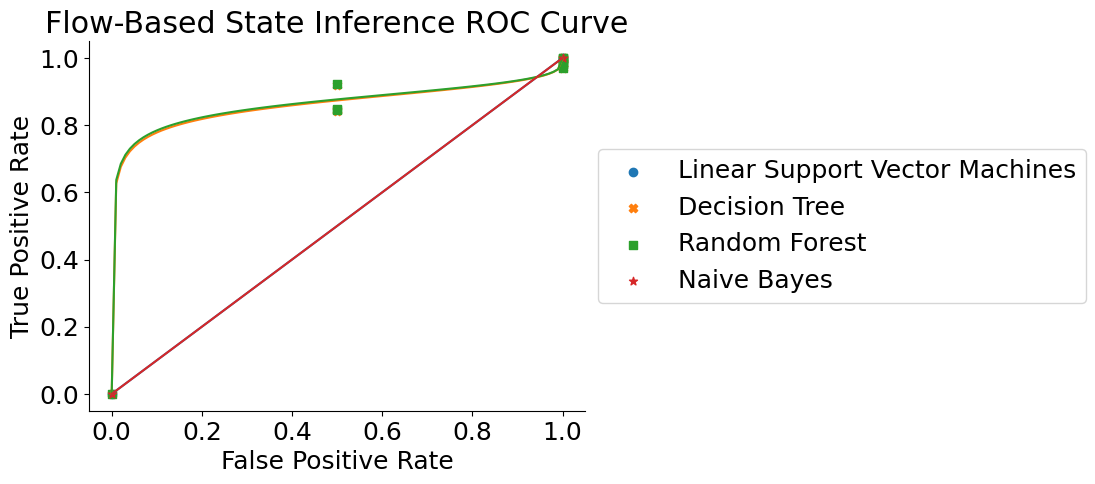

In [12]:
from test_flow_based_classification import LinearSVC, DecisionTreeClassifier, RandomForestClassifier, GaussianNB

models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Tree': DecisionTreeClassifier(),
              'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

roc_curves = {}
df_test_model = flow_based_classification(df_test, models, benign_label='0', t_graph=10, roc_curves=roc_curves, feat_cols=(' Total Fwd Packets', ))
fig = plot_roc_curves(roc_curves, title='Flow-Based State Inference ROC Curve')
df_test_model

# Network Risk Estimation

In [14]:
with open(r'saves/internal_nodes_tuesday.pickle', 'rb') as handle:
    samp_names = pickle.load(handle) 
len(samp_names)

UnpicklingError: invalid load key, '\xef'.

In [6]:
import importlib
import test_nre_classification

importlib.reload(test_nre_classification)
from test_nre_classification import *

In [7]:
df_test, f_list = generate_n_state_flows(2, max_flow_sep=0.4, min_flow_per_sample=5,
                                         max_flow_per_sample=10, date_col='t', label_col='y')
print(df_test)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:30<00:00, 165.68it/s]


                            t  Source IP  Destination IP  Total Fwd Packets   
0     2023-06-06 00:00:00.259          4               3           0.360681  \
1     2023-06-06 00:00:00.471          2               4           0.117564   
2     2023-06-06 00:00:00.821          0               1          -0.688155   
3     2023-06-06 00:00:01.152          3               0           0.363959   
4     2023-06-06 00:00:01.420          0               3            0.33932   
...                       ...        ...             ...                ...   
85274 2023-06-06 07:05:35.232          0               3           0.099427   
85275 2023-06-06 07:05:35.441          0               2          -0.246519   
85276 2023-06-06 07:05:35.734          4               0           0.229641   
85277 2023-06-06 07:05:35.992          3               0          -0.678636   
85278 2023-06-06 07:05:36.201          3               1           0.493408   

       Total Backward Packets  y  
0               

In [3]:
df_test, f_list = simulate_changing_network(min_flow_per_sample=5, max_flow_per_sample=10, date_col='t',
                                                label_col='y')
df_test

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 176.79it/s]


,t,Source IP,Destination IP,Total Fwd Packets,Total Backward Packets,y
0,2023-06-06 00:00:00.258,0,3,-1.784014,0.807369,1
1,2023-06-06 00:00:00.548,2,0,1.103249,-1.784014,1
2,2023-06-06 00:00:00.869,4,0,-0.206927,-1.784014,1
3,2023-06-06 00:00:01.253,3,0,0.807369,-1.784014,1
4,2023-06-06 00:00:01.580,2,0,1.103249,-1.784014,1
...,...,...,...,...,...,...
84844,2023-06-06 07:03:51.309,2,3,1.727707,0.317593,0
84845,2023-06-06 07:03:51.598,0,1,0.393894,0.888522,0
84846,2023-06-06 07:03:51.913,3,1,0.317593,0.888522,0
84847,2023-06-06 07:03:52.303,4,2,2.368473,1.727707,0


In [5]:
f_list

[(array([[1.        , 0.58668192, 0.76405929, 0.21264636, 0.74887306],
         [0.58668192, 1.        , 0.67034747, 0.0367789 , 0.3593748 ],
         [0.76405929, 0.67034747, 1.        , 0.14453883, 0.51115776],
         [0.21264636, 0.0367789 , 0.14453883, 1.        , 0.79167972],
         [0.74887306, 0.3593748 , 0.51115776, 0.79167972, 1.        ]]),
  array([[4.71467411, 0.        , 0.        , 0.        , 0.        ],
         [0.        , 1.01652587, 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.25161565, 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.39058866, 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.44361364]])),
 (array([[1.        , 0.91128111, 0.69880955, 0.76799639, 0.59870061],
         [0.91128111, 1.        , 0.78374592, 0.91667315, 0.76932361],
         [0.69880955, 0.78374592, 1.        , 0.61459906, 0.80250704],
         [0.76799639, 0.91667315, 0.61459906, 1.        , 0.84512752],
 

1
Current time and samples shape:  2023-06-06 00:16:40.389000 (50, 5)
2
Current time and samples shape:  2023-06-06 00:33:20.671000 (50, 5)
3
Current time and samples shape:  2023-06-06 00:50:00.756000 (50, 5)
4
Current time and samples shape:  2023-06-06 01:06:41.040000 (50, 5)
5
Current time and samples shape:  2023-06-06 01:23:21.281000 (50, 5)
6
Current time and samples shape:  2023-06-06 01:40:01.505000 (50, 5)
7
Current time and samples shape:  2023-06-06 01:56:41.551000 (50, 5)
8
Current time and samples shape:  2023-06-06 02:13:21.698000 (50, 5)
9
Current time and samples shape:  2023-06-06 02:30:01.882000 (50, 5)
10
Current time and samples shape:  2023-06-06 02:46:42.140000 (50, 5)
11
Current time and samples shape:  2023-06-06 03:03:22.446000 (50, 5)
12
Current time and samples shape:  2023-06-06 03:20:02.479000 (50, 5)
13
Current time and samples shape:  2023-06-06 03:36:42.748000 (50, 5)
14
Current time and samples shape:  2023-06-06 03:53:22.770000 (50, 5)
15
Current time

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


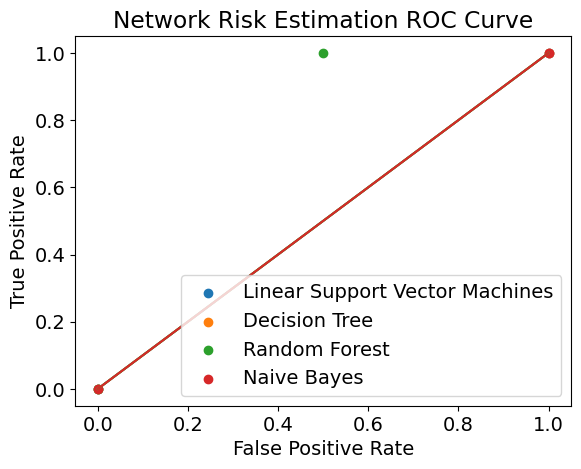

In [8]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Tree': DecisionTreeClassifier(),
              'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

roc_curves = {}
df_test_model = nre_classification(df_test, models, date_col='t', label_col='y', benign_label='0',
                                   t_graph=1000, time_scale='sec', standardize=False, sync_window_size=20,
                                   conn_param=None, roc_curves=roc_curves)
fig = plot_roc_curves(roc_curves, title='Network Risk Estimation ROC Curve')

print(df_test_model)
plt.show()